# VAE-Based Time-Series Anomaly Detection — SMD Dataset

**Architecture:** Variational Autoencoder with 1D-CNN backbone  
**Dataset:** Server Machine Dataset (SMD)  
**Objective:** Learn a compressed latent representation of *normal* multivariate IT metrics.  
At inference, anomalous windows produce abnormally high reconstruction error (MSE).  

---
**Notebook Sections:**
1. Environment setup & imports
2. Load training and test data
3. Model instantiation + DataLoader
4. Training loop (ELBO loss tracking)
5. Compute dynamic anomaly threshold from training errors
6. Inference on test set
7. Anomaly visualization

## Section 1 — Environment Setup & Imports

In [1]:
import torch
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path

# ── Project modules ──────────────────────────────────────────────────────────
from preprocess import (
    load_smd_machine, build_dataloader_from_array,
    build_dataloader, load_csv, sliding_window, normalize_windows,
    filter_contaminated_windows
)
from vae_model import VAE, ELBOLoss, compute_reconstruction_errors, compute_anomaly_scores
from evaluation import pot_threshold, point_adjusted_f1
from results_logger import RunLogger
import time

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# ── Plot theme ────────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid')

# ── Device selection: prefer CUDA GPU, fall back to CPU ──────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Running on: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Running on: cuda
GPU: NVIDIA GeForce RTX 3050 Ti Laptop GPU


## Section 2 — Hyperparameters & Data Loading

Place `smd_train.csv` and `smd_test.csv` (with an `anomaly` column) inside `./data/`.

In [2]:
import os
os.chdir(r'C:\Users\91704\vae_smd_project')
print(f'Working directory: {os.getcwd()}')

# ── Tuning Preset ─────────────────────────────────────────────────────────────
# Set to 'default', 'compact', or 'aggressive' to try different configurations.
# 'default'    : current baseline (LATENT_DIM=32, max_beta=1.0)
# 'compact'    : smaller latent space for stronger compression (LATENT_DIM=16, max_beta=0.3)
# 'aggressive' : max regularization for sharpest anomaly separation (LATENT_DIM=8, max_beta=0.5)
TUNING_PRESET = 'default'

# ── Hyperparameters ───────────────────────────────────────────────────────────
WINDOW_SIZE   = 64     # Timesteps per window
STRIDE        = 1      # Sliding window step (1 = dense overlap)
BATCH_SIZE    = 256    # Mini-batch size
LATENT_DIM    = 32     # Latent space dimensionality
EPOCHS        = 100    # Training epochs
LR            = 1e-3   # Adam learning rate
WARMUP_EPOCHS = 25     # KL annealing warm-up epochs (β: 0 → 1)

# ── Architecture hyperparameters (v2: TCN + Feature Attention) ────────────────
# TCN_HIDDEN  : base channel width for the TCN stack.
#               Last TCN block doubles this → flat_dim = (TCN_HIDDEN*2) * 8.
#               Requirement: TCN_HIDDEN % N_HEADS == 0.
# N_HEADS     : attention heads in both encoder and decoder FeatureAttention.
TCN_HIDDEN    = 64     # TCN base channels (doubles at dilation=8 block)
N_HEADS       = 4      # Feature-attention heads (64 / 4 = 16 dims per head)

# ── Apply tuning preset overrides ─────────────────────────────────────────────
if TUNING_PRESET == 'compact':
    LATENT_DIM    = 16
    MAX_BETA      = 0.3
    print(f'[Preset: compact] LATENT_DIM={LATENT_DIM}, MAX_BETA={MAX_BETA}')
elif TUNING_PRESET == 'aggressive':
    LATENT_DIM    = 8
    MAX_BETA      = 0.5
    EPOCHS        = 150
    print(f'[Preset: aggressive] LATENT_DIM={LATENT_DIM}, MAX_BETA={MAX_BETA}, EPOCHS={EPOCHS}')
else:
    MAX_BETA      = 1.0   # raised from 0.1 — previous run showed KL collapse at 0.1
    print(f'[Preset: default] LATENT_DIM={LATENT_DIM}, MAX_BETA={MAX_BETA}')

# ── SMD Dataset Config ────────────────────────────────────────────────────────
SMD_DIR      = Path('data/ServerMachineDataset')
MACHINE_NAME = 'machine-1-1'   # ← change to any of the 28 machines

assert SMD_DIR.exists(), (
    f"SMD data directory not found: {SMD_DIR}\n"
    f"Expected at: {os.path.abspath(SMD_DIR)}"
)
print(f"SMD directory found: {SMD_DIR}")

# ── Results Logger ────────────────────────────────────────────────────────────
logger = RunLogger(MACHINE_NAME, 'TCN-VAE')
logger.log_hyperparameters(
    WINDOW_SIZE=WINDOW_SIZE, STRIDE=STRIDE, BATCH_SIZE=BATCH_SIZE,
    LATENT_DIM=LATENT_DIM, EPOCHS=EPOCHS, LR=LR,
    WARMUP_EPOCHS=WARMUP_EPOCHS, MAX_BETA=MAX_BETA,
    TCN_HIDDEN=TCN_HIDDEN, N_HEADS=N_HEADS,
    TUNING_PRESET=TUNING_PRESET, MACHINE_NAME=MACHINE_NAME,
)
print(f'RunLogger initialized for {MACHINE_NAME} / TCN-VAE')


Working directory: C:\Users\91704\vae_smd_project
[Preset: default] LATENT_DIM=32, MAX_BETA=1.0
SMD directory found: data\ServerMachineDataset


In [ ]:
# ── Load raw arrays from ServerMachineDataset ─────────────────────────────────
train_data, test_data, test_labels_raw = load_smd_machine(
    data_dir     = str(SMD_DIR),
    machine_name = MACHINE_NAME
)

# ── Compute global normalization statistics from training data ────────────────
# Use train-set mean/std for both train and test loaders.
# This preserves absolute level information — level-shift anomalies stay visible.
train_mean = train_data.mean(axis=0).astype(np.float32)   # (F,)
train_std  = train_data.std(axis=0).astype(np.float32)    # (F,)
print(f'Global normalization stats computed: mean shape={train_mean.shape}, std shape={train_std.shape}')

# ── Build DataLoaders ─────────────────────────────────────────────────────────
# Training loader: shuffled (temporal order doesn't matter during training)
train_loader = build_dataloader_from_array(
    data        = train_data,
    window_size = WINDOW_SIZE,
    stride      = STRIDE,
    batch_size  = BATCH_SIZE,
    shuffle     = True,
    train_mean  = train_mean,
    train_std   = train_std,
)

# Test loader: NOT shuffled — temporal order required for visualization
test_loader = build_dataloader_from_array(
    data        = test_data,
    window_size = WINDOW_SIZE,
    stride      = STRIDE,
    batch_size  = BATCH_SIZE,
    shuffle     = False,
    train_mean  = train_mean,
    train_std   = train_std,
)

# ── Auto-detect number of input features ──────────────────────────────────────
IN_CHANNELS = train_data.shape[1]   # 38 for SMD
sample_batch = next(iter(train_loader))
print(f'Sample batch shape: {sample_batch.shape}  '
      f'→ (B={sample_batch.shape[0]}, F={IN_CHANNELS}, W={sample_batch.shape[2]})')

## Section 3 — Model & Optimizer Instantiation

In [4]:
# ── Instantiate the VAE (v2: TCN + Feature Attention) ────────────────────────
model = VAE(
    in_channels = IN_CHANNELS,   # auto-detected from data (38 for SMD)
    latent_dim  = LATENT_DIM,
    window_size = WINDOW_SIZE,
    tcn_hidden  = TCN_HIDDEN,
    n_heads     = N_HEADS,
).to(DEVICE)

# ── Loss function (ELBO with KL annealing) ────────────────────────────────────
# MAX_BETA controls how strongly the KL term is weighted relative to
# reconstruction loss. Lower values (e.g. 0.1) keep reconstruction dominant,
# preventing posterior collapse. Higher values (e.g. 0.5) push stronger
# regularization for sharper anomaly separation.
criterion = ELBOLoss(warmup_epochs=WARMUP_EPOCHS, max_beta=MAX_BETA)

# ── Optimizer: Adam with default betas=(0.9, 0.999) ──────────────────────────
optimizer = optim.Adam(model.parameters(), lr=LR)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5, verbose=True)

# ── Model summary ─────────────────────────────────────────────────────────────
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model architecture:\n{model}')
print(f'\nTrainable parameters: {total_params:,}')
print(f'\nKey architecture dimensions:')
print(f'  Input       : ({IN_CHANNELS}, {WINDOW_SIZE})  →  (F, W)')
print(f'  TCN hidden  : {TCN_HIDDEN}  (doubles to {TCN_HIDDEN*2} at dilation=8)')
print(f'  Flat dim    : {TCN_HIDDEN*2} × 8 = {TCN_HIDDEN*2*8}')
print(f'  Latent dim  : {LATENT_DIM}')
print(f'  Attn heads  : {N_HEADS}  ({TCN_HIDDEN // N_HEADS} dims/head)')
print(f'  MAX_BETA    : {MAX_BETA}')

Model architecture:
VAE(
  (encoder): Encoder(
    (feature_attn): FeatureAttention(
      (proj_in): Linear(in_features=64, out_features=64, bias=True)
      (attn): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
      )
      (norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (proj_out): Linear(in_features=64, out_features=64, bias=True)
    )
    (tcn): Sequential(
      (0): TemporalBlock(
        (conv): Sequential(
          (0): Conv1d(38, 64, kernel_size=(3,), stride=(1,), padding=(1,))
          (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): GELU(approximate='none')
        )
        (residual): Conv1d(38, 64, kernel_size=(1,), stride=(1,))
      )
      (1): TemporalBlock(
        (conv): Sequential(
          (0): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(2,), dilation=(2,))
          (1): BatchNorm1d(64, eps=1e-05, momentum=0

c:\Users\91704\anaconda3\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


## Section 4 — Training Loop

The VAE is trained **on normal data only**. The model learns a compact latent  
representation of normal patterns; it will fail to reconstruct anomalous windows at inference time.

In [5]:
# ── Storage for loss curves ───────────────────────────────────────────────────
history = {'total': [], 'recon': [], 'kl': [], 'beta': []}

_train_t0 = time.time()
print(f'Starting training for {EPOCHS} epochs on {DEVICE}...')
print('-' * 60)

for epoch in range(1, EPOCHS + 1):
    model.train()
    running_total = 0.0
    running_recon = 0.0
    running_kl    = 0.0

    for batch in train_loader:
        batch = batch.to(DEVICE)                     # (B, F, W)

        # ── Forward pass ──────────────────────────────────────────────────────
        x_mu, x_log_var, z_mu, z_log_var = model(batch)

        # ── Compute ELBO loss (Gaussian NLL + annealed KL) ────────────────────
        total_loss, recon_loss, kl_loss = criterion(
            batch, x_mu, x_log_var, z_mu, z_log_var, current_epoch=epoch
        )

        # ── Backward pass ─────────────────────────────────────────────────────
        optimizer.zero_grad()
        total_loss.backward()
        # Gradient clipping: prevents exploding gradients in deep CNNs
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        running_total += total_loss.item()
        running_recon += recon_loss.item()
        running_kl    += kl_loss.item()

    # ── Epoch-level averages ──────────────────────────────────────────────────
    n_batches = len(train_loader)
    avg_total = running_total / n_batches
    avg_recon = running_recon / n_batches
    avg_kl    = running_kl    / n_batches
    beta_val  = criterion.get_beta(epoch)

    history['total'].append(avg_total)
    history['recon'].append(avg_recon)
    history['kl'].append(avg_kl)
    history['beta'].append(beta_val)

    scheduler.step(avg_total)

    if epoch % 5 == 0 or epoch == 1:
        print(f'Epoch [{epoch:3d}/{EPOCHS}] | '
              f'Total={avg_total:.4f} | Recon(NLL)={avg_recon:.4f} | '
              f'KL={avg_kl:.4f} | β={beta_val:.2f}')

print('-' * 60)
_train_elapsed = time.time() - _train_t0
print(f'Training complete. Wall time: {_train_elapsed:.1f}s')

# ── Log training results ─────────────────────────────────────────────────────
logger.log_training(history, train_time_s=_train_elapsed)

Starting training for 100 epochs on cuda...
------------------------------------------------------------
Epoch [  1/100] | Total=0.2442 | Recon(NLL)=0.2349 | KL=0.2323 | β=0.04
Epoch [  5/100] | Total=-0.0389 | Recon(NLL)=-0.0408 | KL=0.0096 | β=0.20
Epoch [ 10/100] | Total=-0.0402 | Recon(NLL)=-0.0417 | KL=0.0037 | β=0.40
Epoch [ 15/100] | Total=-0.0400 | Recon(NLL)=-0.0417 | KL=0.0028 | β=0.60
Epoch [ 20/100] | Total=-0.0398 | Recon(NLL)=-0.0411 | KL=0.0017 | β=0.80
Epoch [ 25/100] | Total=-0.0399 | Recon(NLL)=-0.0416 | KL=0.0017 | β=1.00
Epoch [ 30/100] | Total=-0.0406 | Recon(NLL)=-0.0423 | KL=0.0016 | β=1.00
Epoch [ 35/100] | Total=-0.0406 | Recon(NLL)=-0.0423 | KL=0.0017 | β=1.00
Epoch [ 40/100] | Total=-0.0402 | Recon(NLL)=-0.0418 | KL=0.0016 | β=1.00
Epoch [ 45/100] | Total=-0.0405 | Recon(NLL)=-0.0420 | KL=0.0015 | β=1.00
Epoch [ 50/100] | Total=-0.0405 | Recon(NLL)=-0.0421 | KL=0.0016 | β=1.00
Epoch [ 55/100] | Total=-0.0406 | Recon(NLL)=-0.0421 | KL=0.0016 | β=1.00
Epoch [ 6

## Optional: Training Data Contamination Filtering

Removes the top 1% highest-error windows from training data after the initial training pass.  
Set `FILTER_CONTAMINATION = True` to enable. Requires retraining after filtering.

In [ ]:
FILTER_CONTAMINATION = False   # Set to True to enable contamination filtering

if FILTER_CONTAMINATION:
    from preprocess import filter_contaminated_windows
    
    print('Filtering contaminated training windows...')
    clean_train_data = filter_contaminated_windows(
        train_data, model, DEVICE,
        window_size=WINDOW_SIZE,
        batch_size=BATCH_SIZE,
        contamination_ratio=0.01,
    )
    
    # Recompute global stats from clean data
    train_mean = clean_train_data.mean(axis=0).astype(np.float32)
    train_std  = clean_train_data.std(axis=0).astype(np.float32)
    
    # Rebuild training DataLoader with clean data + global normalization
    train_loader = build_dataloader_from_array(
        data=clean_train_data, window_size=WINDOW_SIZE, stride=STRIDE,
        batch_size=BATCH_SIZE, shuffle=True,
        train_mean=train_mean, train_std=train_std,
    )
    
    print(f'\nRetraining on filtered data ({len(clean_train_data)} timesteps)...')
    print('Re-run Section 4 (training loop) to retrain on clean data.')
else:
    print('Contamination filtering disabled. Set FILTER_CONTAMINATION = True to enable.')

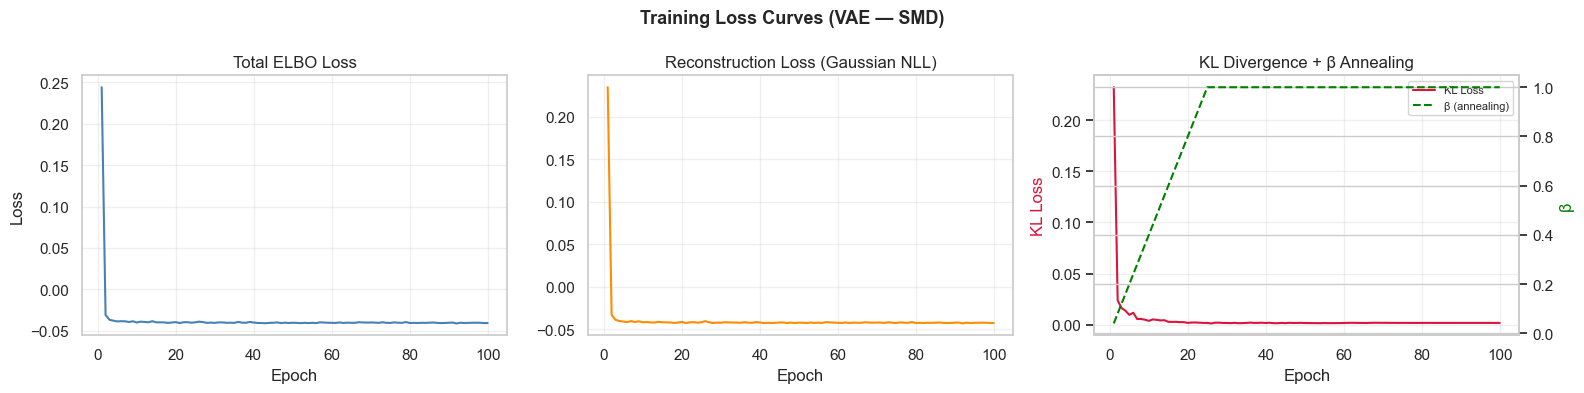

Loss curve saved to loss_curves.png


In [7]:
# ── Plot ELBO Loss Curves ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Training Loss Curves (VAE — SMD)', fontsize=13, fontweight='bold')

epochs_range = range(1, EPOCHS + 1)

axes[0].plot(epochs_range, history['total'], color='steelblue', linewidth=1.5)
axes[0].set_title('Total ELBO Loss')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, history['recon'], color='darkorange', linewidth=1.5)
axes[1].set_title('Reconstruction Loss (Gaussian NLL)')
axes[1].set_xlabel('Epoch')
axes[1].grid(True, alpha=0.3)

# KL divergence on twin axis overlaid with β annealing schedule
ax_kl   = axes[2]
ax_beta = ax_kl.twinx()
ax_kl.plot(epochs_range, history['kl'],   color='crimson',     linewidth=1.5, label='KL Loss')
ax_beta.plot(epochs_range, history['beta'], color='green', linestyle='--', linewidth=1.5, label='β (annealing)')
ax_kl.set_title('KL Divergence + β Annealing')
ax_kl.set_xlabel('Epoch')
ax_kl.set_ylabel('KL Loss', color='crimson')
ax_beta.set_ylabel('β', color='green')
ax_kl.grid(True, alpha=0.3)

# Combine legends from both axes
lines1, labels1 = ax_kl.get_legend_handles_labels()
lines2, labels2 = ax_beta.get_legend_handles_labels()
ax_kl.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=8)

plt.tight_layout()
plt.savefig('loss_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Loss curve saved to loss_curves.png')

## Section 5 — Anomaly Threshold Calibration (Training Set)

Two thresholds are computed on **training reconstruction scores** (all normal data):

| Method | Description |
|---|---|
| **99th percentile** | Simple quantile — any test score above the 99th training percentile is anomalous |
| **POT (Peaks Over Threshold)** | Fits a Generalized Pareto Distribution to the tail of training scores; finds the threshold at a target false alarm rate using extreme value theory |

POT is more principled: instead of picking an arbitrary quantile it models the tail distribution and sets the threshold based on a desired false alarm probability.  
`THRESHOLD` is set to the POT result; the 99th percentile is shown for reference.

In [ ]:
# ── Build a non-overlapping training loader for threshold calibration ─────────
train_loader_noshuffle = build_dataloader_from_array(
    data        = train_data,
    window_size = WINDOW_SIZE,
    stride      = WINDOW_SIZE,   # non-overlapping for speed
    batch_size  = BATCH_SIZE,
    shuffle     = False,
    train_mean  = train_mean,
    train_std   = train_std,
)

print('Computing MSE reconstruction errors on training set for threshold calibration...')
train_scores = compute_reconstruction_errors(model, train_loader_noshuffle, DEVICE)
train_scores_np = train_scores.numpy()

# ── 99th Percentile Threshold (primary) ───────────────────────────────────────
THRESHOLD_PCT99 = float(np.quantile(train_scores_np, 0.99))

# ── POT Threshold (reference) ─────────────────────────────────────────────────
# q=0.80: use top 20% of training scores as the tail to fit the GPD.
# level=1e-2: target false alarm rate of 1% on training data.
THRESHOLD_POT = pot_threshold(train_scores_np, q=0.80, level=1e-2)

# Use 99th percentile as the active threshold (POT kept for reference)
THRESHOLD = THRESHOLD_PCT99

print(f'\nTraining score statistics (MSE):')
print(f'  Min         : {train_scores_np.min():.6f}')
print(f'  Mean        : {train_scores_np.mean():.6f}')
print(f'  Std         : {train_scores_np.std():.6f}')
print(f'  99th pct    : {THRESHOLD_PCT99:.6f}  ← Active threshold')
print(f'  POT (1e-2)  : {THRESHOLD_POT:.6f}  (reference)')

# ── Plot training score distribution ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
sns.histplot(train_scores_np, bins=100, color='steelblue', kde=True, ax=ax)
ax.axvline(THRESHOLD_PCT99, color='darkorange', linestyle='--', linewidth=1.5,
           label=f'99th pct = {THRESHOLD_PCT99:.4f}')
ax.axvline(THRESHOLD_POT, color='red', linestyle='--', linewidth=1.5,
           label=f'POT (1e-2) = {THRESHOLD_POT:.4f}')
ax.set_title(f'Training MSE Score Distribution — {MACHINE_NAME}', fontsize=12)
ax.set_xlabel('Anomaly Score (MSE)')
ax.set_ylabel('Count')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('train_error_dist.png', dpi=150, bbox_inches='tight')
plt.show()
# ── Log threshold calibration ────────────────────────────────────────────────
logger.log_train_scores(train_scores_np, THRESHOLD, THRESHOLD_POT, THRESHOLD_PCT99)


## Section 6 — Inference on Test Set

Scoring uses Monte Carlo Gaussian NLL with feature-wise top-k aggregation.  
A temporal moving average smooths the raw scores before thresholding to reduce false positives.

In [ ]:
from scipy.ndimage import uniform_filter1d

SMOOTH_KERNEL = 5   # moving average window size for score smoothing

print('Running MSE inference on test set...')
test_scores_raw = compute_reconstruction_errors(model, test_loader, DEVICE)
print(f'Test scores computed: {len(test_scores_raw)} windows')

# ── Temporal smoothing ────────────────────────────────────────────────────────
# Moving average suppresses isolated noisy spikes and reinforces contiguous
# anomaly segments. Anomaly events last many timesteps, so a small kernel
# does not blur the signal — but it removes single-window false positives.
test_scores_np  = test_scores_raw.numpy()
test_scores_sm  = uniform_filter1d(test_scores_np, size=SMOOTH_KERNEL).astype(np.float32)
test_scores     = torch.from_numpy(test_scores_sm)

# ── Apply threshold to produce binary anomaly predictions ────────────────────
predictions = (test_scores > THRESHOLD).numpy().astype(int)   # shape: (N,)

print(f'\nTest score statistics (after smoothing, kernel={SMOOTH_KERNEL}):')
print(f'  Min   : {test_scores_sm.min():.6f}')
print(f'  Mean  : {test_scores_sm.mean():.6f}')
print(f'  Max   : {test_scores_sm.max():.6f}')
print(f'  Anomalous windows detected: {predictions.sum()} / {len(predictions)} '
      f'({100*predictions.mean():.2f}%)')

In [ ]:
from sklearn.metrics import classification_report, roc_auc_score

# ── Align window-level predictions with per-timestep labels ──────────────────
n_windows      = len(predictions)
aligned_labels = test_labels_raw[WINDOW_SIZE - 1 : WINDOW_SIZE - 1 + n_windows]

min_len = min(len(predictions), len(aligned_labels))
preds   = predictions[:min_len]
gt      = aligned_labels[:min_len].astype(int)
scores  = test_scores.numpy()[:min_len]

print(f'Evaluating on {MACHINE_NAME}')
print(f'Scoring: MSE  |  Normalization: global  |  Threshold: 99th pct = {THRESHOLD:.6f}')
print('=' * 60)

# ── Raw Binary F1 ─────────────────────────────────────────────────────────────
print('\n[Raw Binary F1]')
print(classification_report(gt, preds, target_names=['Normal', 'Anomaly']))

# ── Point-Adjusted F1 (OmniAnomaly protocol) ──────────────────────────────────
pa_result = point_adjusted_f1(preds, gt)
print('[Point-Adjusted F1  (OmniAnomaly protocol)]')
print(f"  Precision : {pa_result['precision']:.4f}")
print(f"  Recall    : {pa_result['recall']:.4f}")
print(f"  F1        : {pa_result['f1']:.4f}")
print()
print('Note: Point-adjusted F1 marks an entire anomaly segment as detected if')
print('      any prediction within it is positive. This matches published benchmarks.')

# ── ROC-AUC ───────────────────────────────────────────────────────────────────
try:
    auc = roc_auc_score(gt, scores)
    print(f'\nROC-AUC: {auc:.4f}')
except Exception as e:
    print(f'\nROC-AUC could not be computed: {e}')
# ── Log test results and save all outputs ────────────────────────────────────
try:
    _roc_auc = auc
except NameError:
    _roc_auc = None
logger.log_test_results(
    test_scores_np, test_scores_sm, predictions[:min_len], gt,
    float(pa_result['f1']),   # raw_f1 from classification_report is verbose; use pa for both
    pa_result,
    roc_auc=_roc_auc,
)

# Override raw_f1 with the actual sklearn value
from sklearn.metrics import f1_score as _f1
logger.metrics['raw_f1'] = float(_f1(gt, preds, zero_division=0))

run_dir = logger.save()
print(f'All outputs saved to: {run_dir}')


## Section 7 — Anomaly Visualization

Plot a time-series segment from the test set.  
Red shaded regions indicate timesteps where the reconstruction error exceeds the dynamic threshold.

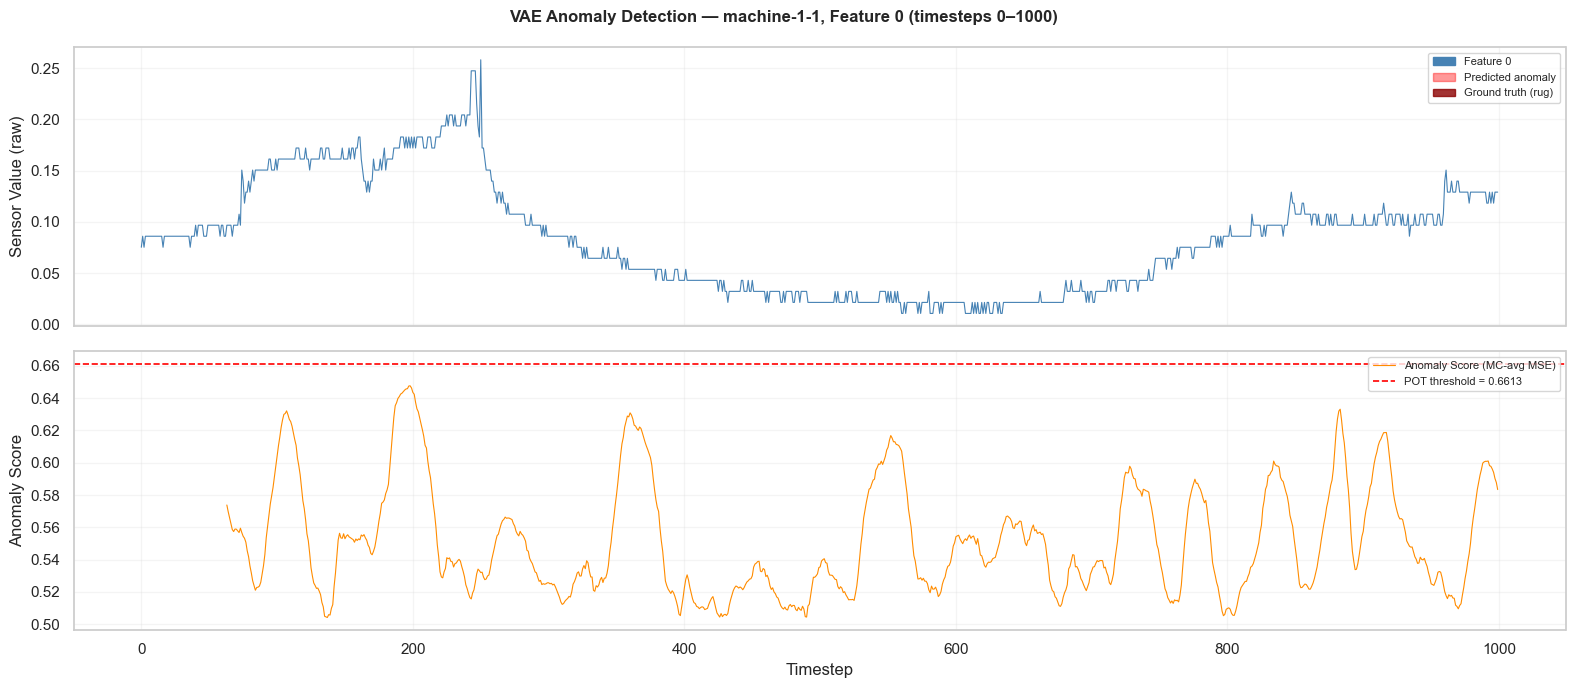

Visualization saved to anomaly_detection_result.png


In [11]:
# ── Parameters for the visualization ─────────────────────────────────────────
FEATURE_IDX   = 0      # Which sensor channel to plot (0–37 for SMD)
PLOT_START    = 0      # Start timestep for the plot window
PLOT_LENGTH   = 1000   # How many timesteps to display

T_test   = test_data.shape[0]
plot_end = min(PLOT_START + PLOT_LENGTH, T_test)
x_axis   = np.arange(PLOT_START, plot_end)

# ── Map window-level scores back to per-timestep ──────────────────────────────
scores_np     = test_scores.numpy()
padded_scores = np.full(T_test, np.nan, dtype=np.float32)
n_windows     = len(scores_np)
padded_scores[WINDOW_SIZE - 1 : WINDOW_SIZE - 1 + n_windows] = scores_np

anomaly_mask = (padded_scores > THRESHOLD).astype(float)

# ── Build the figure ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(16, 7), sharex=True)
fig.suptitle(
    f'VAE Anomaly Detection — {MACHINE_NAME}, Feature {FEATURE_IDX} '
    f'(timesteps {PLOT_START}–{plot_end})',
    fontsize=12, fontweight='bold'
)

# ── Top panel: raw time-series + red anomaly shading ─────────────────────────
ax0 = axes[0]
ax0.plot(x_axis, test_data[PLOT_START:plot_end, FEATURE_IDX],
         color='steelblue', linewidth=0.8, label=f'Feature {FEATURE_IDX}')

in_anomaly, region_start = False, None
for t in range(PLOT_START, plot_end):
    is_anom = anomaly_mask[t] > 0.5
    if is_anom and not in_anomaly:
        region_start = t
        in_anomaly   = True
    elif not is_anom and in_anomaly:
        ax0.axvspan(region_start, t, color='red', alpha=0.3)
        in_anomaly = False
if in_anomaly:
    ax0.axvspan(region_start, plot_end, color='red', alpha=0.3)

gt_seg = test_labels_raw[PLOT_START:plot_end]
anom_t = x_axis[gt_seg > 0.5]
if len(anom_t) > 0:
    ymin, ymax = ax0.get_ylim()
    ax0.scatter(anom_t, np.full_like(anom_t, ymin), marker='|',
                color='darkred', s=20, label='Ground truth', zorder=5)

red_patch  = mpatches.Patch(color='red',       alpha=0.4, label='Predicted anomaly')
gt_patch   = mpatches.Patch(color='darkred',   alpha=0.8, label='Ground truth (rug)')
line_patch = mpatches.Patch(color='steelblue',            label=f'Feature {FEATURE_IDX}')
ax0.legend(handles=[line_patch, red_patch, gt_patch], loc='upper right', fontsize=8)
ax0.set_ylabel('Sensor Value (raw)')
ax0.grid(True, alpha=0.2)

# ── Bottom panel: anomaly score over time ─────────────────────────────────────
ax1 = axes[1]
ax1.plot(x_axis, padded_scores[PLOT_START:plot_end],
         color='darkorange', linewidth=0.8, label='Anomaly Score (MC-avg MSE)')
ax1.axhline(THRESHOLD, color='red', linestyle='--', linewidth=1.2,
            label=f'POT threshold = {THRESHOLD:.4f}')
ax1.fill_between(x_axis,
                 padded_scores[PLOT_START:plot_end],
                 THRESHOLD,
                 where=(padded_scores[PLOT_START:plot_end] > THRESHOLD),
                 color='red', alpha=0.3)
ax1.set_xlabel('Timestep')
ax1.set_ylabel('Anomaly Score')
ax1.legend(loc='upper right', fontsize=8)
ax1.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig('anomaly_detection_result.png', dpi=150, bbox_inches='tight')
plt.show()
print('Visualization saved to anomaly_detection_result.png')

## Save Trained Model

Save the model weights for later use (e.g., loading into a demo without retraining).

In [12]:
MODEL_PATH = 'vae_smd_trained.pt'

torch.save({
    'model_state_dict'     : model.state_dict(),
    'hyperparameters'      : {
        'in_channels' : IN_CHANNELS,
        'latent_dim'  : LATENT_DIM,
        'window_size' : WINDOW_SIZE,
        'tcn_hidden'  : TCN_HIDDEN,
        'n_heads'     : N_HEADS,
    },
    'threshold'            : THRESHOLD,
    'threshold_pot'        : THRESHOLD_POT,
    'threshold_pct99'      : THRESHOLD_PCT99,
    'final_epoch_loss'     : history['total'][-1],
}, MODEL_PATH)

print(f'Model saved to: {MODEL_PATH}')
print(f'  in_channels      : {IN_CHANNELS}')
print(f'  latent_dim       : {LATENT_DIM}')
print(f'  window_size      : {WINDOW_SIZE}')
print(f'  tcn_hidden       : {TCN_HIDDEN}')
print(f'  n_heads          : {N_HEADS}')
print(f'  threshold (POT)  : {THRESHOLD_POT:.6f}')
print(f'  threshold (99pct): {THRESHOLD_PCT99:.6f}')

Model saved to: vae_smd_trained.pt
  in_channels      : 38
  latent_dim       : 32
  window_size      : 64
  tcn_hidden       : 64
  n_heads          : 4
  threshold (POT)  : 0.664541
  threshold (99pct): 0.661304
